<a href="https://colab.research.google.com/github/PihuCodeTech/Aircraft-Engine-RUL-Prediction/blob/main/rul_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.optimize import minimize
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Bidirectional, Dense, Dropout,
                                     Conv1D, BatchNormalization, MaxPooling1D,
                                     Flatten, Multiply, Add, LayerNormalization,
                                     GlobalAveragePooling1D, MultiHeadAttention)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED            = 42
SEQUENCE_LENGTH = 30
RUL_THRESHOLD   = 125
N_SPLITS        = 5
tf.random.set_seed(SEED)
np.random.seed(SEED)


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. RAW DATA LOADING ONLY — no scaling, no feature engineering yet
# ══════════════════════════════════════════════════════════════════════════════
train_df = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None)
train_df.columns = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

max_cycle       = train_df.groupby('id')['cycle'].max().reset_index().rename(columns={'cycle':'max_cycle'})
train_df        = train_df.merge(max_cycle, on='id')
train_df['RUL'] = (train_df['max_cycle'] - train_df['cycle']).clip(upper=RUL_THRESHOLD)
train_df.drop(columns=['max_cycle'], inplace=True)

# base sensor + op cols only — NO scaling, NO smoothing, NO rolling yet
base_feature_cols = [c for c in train_df.columns if c not in ['id','cycle','RUL']]

# ══════════════════════════════════════════════════════════════════════════════
# 2. FEATURE ENGINEERING FUNCTION (applied per fold on train/val separately)
# ══════════════════════════════════════════════════════════════════════════════
def engineer_features(df, base_cols):
    """
    Apply all feature engineering to a dataframe.
    Must be called separately on train and val splits
    so no information crosses the fold boundary.
    Returns: engineered dataframe, final feature column list
    """
    df = df.copy()

    # Cycle progress — per engine, uses only that engine's cycles ✅
    feat_cols = base_cols.copy()
    # EWM smoothing — per engine only, no cross-engine leakage ✅
    for col in feat_cols:
        df[col] = df.groupby('id')[col].transform(
            lambda x: x.ewm(alpha=0.3, adjust=False).mean()
        )

    # Rolling mean — per engine only ✅
    roll_cols = []
    for col in feat_cols:
        nc = f'{col}_roll5'
        df[nc] = df.groupby('id')[col].transform(
            lambda x: x.rolling(5, min_periods=1).mean()
        )
        roll_cols.append(nc)

    all_feat_cols = feat_cols + roll_cols
    return df, all_feat_cols

# ══════════════════════════════════════════════════════════════════════════════
# 3. SEQUENCE CREATION
# ══════════════════════════════════════════════════════════════════════════════
def create_sequences(df, feat_cols, seq_len):
    X_seqs, y_seqs = [], []
    for eid in df['id'].unique():
        engine = df[df['id'] == eid]
        arr    = engine[feat_cols + ['RUL']].values
        for i in range(len(arr) - seq_len):
            X_seqs.append(arr[i:i+seq_len, :-1])
            y_seqs.append(arr[i+seq_len,   -1])
    return np.array(X_seqs, dtype=np.float32), np.array(y_seqs, dtype=np.float32)

# ══════════════════════════════════════════════════════════════════════════════
# 4. NASA SCORE & METRICS
# ══════════════════════════════════════════════════════════════════════════════
def nasa_score(y_true, y_pred):
    diff = y_pred - y_true
    return float(np.sum(np.where(diff < 0,
                                 np.exp(-diff/13) - 1,
                                 np.exp( diff/10) - 1)))

def report_metrics(name, true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae  = mean_absolute_error(true, pred)
    nasa = nasa_score(true, pred)
    print(f"{name:35s} → RMSE:{rmse:.3f}  MAE:{mae:.3f}  NASA:{nasa:.1f}")
    return rmse, mae, nasa


In [3]:

# ══════════════════════════════════════════════════════════════════════════════
# 5. MODEL BUILDERS
# ══════════════════════════════════════════════════════════════════════════════
def build_bilstm(seq_len, n_features):
    inputs  = Input(shape=(seq_len, n_features))
    x       = Bidirectional(LSTM(64, return_sequences=True, recurrent_dropout=0.05))(inputs)
    x       = Dropout(0.1)(x)
    attn    = MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.05)(x, x)
    x       = LayerNormalization()(Add()([x, attn]))
    ffn     = Dense(128, activation='relu')(x)
    ffn     = Dense(x.shape[-1])(ffn)
    x       = LayerNormalization()(Add()([x, ffn]))
    x       = GlobalAveragePooling1D()(x)
    x       = Dense(64, activation='relu')(x)
    x       = Dropout(0.1)(x)
    outputs = Dense(1)(x)
    model   = Model(inputs, outputs)
    model.compile(optimizer=Adam(8e-5), loss=Huber(), metrics=['mae'])
    return model

def build_cnn(seq_len, n_features):
    inputs  = Input(shape=(seq_len, n_features))
    x       = Conv1D(64, kernel_size=3, activation='relu')(inputs)
    x       = BatchNormalization()(x)
    x       = MaxPooling1D(pool_size=2)(x)
    x       = Dropout(0.2)(x)
    x       = Conv1D(32, kernel_size=3, activation='relu')(x)
    x       = BatchNormalization()(x)
    w       = Dense(32, activation='softmax')(x)
    x       = Flatten()(Multiply()([x, w]))
    x       = Dense(64, activation='relu')(x)
    x       = Dropout(0.3)(x)
    outputs = Dense(1)(x)
    model   = Model(inputs, outputs)
    model.compile(optimizer=Adam(1e-3), loss=Huber(), metrics=['mae'])
    return model

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 6. CALLBACKS
# ══════════════════════════════════════════════════════════════════════════════
def get_callbacks_bilstm():
    return [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=6, min_lr=1e-6, verbose=0)
    ]

def get_callbacks_cnn():
    return [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=5, min_lr=1e-5, verbose=0)
    ]


In [5]:

# ══════════════════════════════════════════════════════════════════════════════
# 7. GROUPKFOLD LOOP — scaler fitted inside fold on train only
# ══════════════════════════════════════════════════════════════════════════════
engine_ids  = train_df['id'].unique()
gkf         = GroupKFold(n_splits=N_SPLITS)

fold_results             = []
lstm_histories           = []
cnn_histories            = []
all_val_lstm             = []
all_val_cnn              = []
all_val_true             = []

# keep final fold scaler for test preprocessing
final_fold_scaler        = None
final_fold_feat_cols     = None

for fold, (train_eng_idx, val_eng_idx) in enumerate(
        gkf.split(engine_ids, groups=engine_ids)):

    print(f"\n{'='*55}")
    print(f"  FOLD {fold+1} / {N_SPLITS}")
    print(f"{'='*55}")

    train_engines = engine_ids[train_eng_idx]
    val_engines   = engine_ids[val_eng_idx]

    # ── Raw split by engine ────────────────────────────────────────────────────
    train_raw = train_df[train_df['id'].isin(train_engines)].copy()
    val_raw   = train_df[train_df['id'].isin(val_engines)].copy()

    # ── Feature engineering separately on each split ──────────────────────────
    train_eng, feat_cols = engineer_features(train_raw, base_feature_cols)
    val_eng,   _         = engineer_features(val_raw,   base_feature_cols)

    # ── Scaler fitted on TRAIN only, applied to both ── ← fixes leakage ──────
    fold_scaler = MinMaxScaler(feature_range=(0, 1))
    train_eng[feat_cols] = fold_scaler.fit_transform(train_eng[feat_cols])
    val_eng[feat_cols]   = fold_scaler.transform(val_eng[feat_cols])     # ← transform only

    # keep last fold's scaler & feat_cols for test set
    final_fold_scaler    = fold_scaler
    final_fold_feat_cols = feat_cols

    # ── Sequences ─────────────────────────────────────────────────────────────
    X_train, y_train = create_sequences(train_eng, feat_cols, SEQUENCE_LENGTH)
    X_val,   y_val   = create_sequences(val_eng,   feat_cols, SEQUENCE_LENGTH)
    print(f"  Train: {X_train.shape} | Val: {X_val.shape}")

    n_features = X_train.shape[2]

    # ── Fresh models every fold ────────────────────────────────────────────────
    bilstm_model = build_bilstm(SEQUENCE_LENGTH, n_features)
    cnn_model    = build_cnn(SEQUENCE_LENGTH, n_features)

    h_lstm = bilstm_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=60, batch_size=64,
        callbacks=get_callbacks_bilstm(), verbose=0
    )
    h_cnn = cnn_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=60, batch_size=64,
        callbacks=get_callbacks_cnn(), verbose=0
    )

    lstm_histories.append(h_lstm)
    cnn_histories.append(h_cnn)

    vp_lstm = bilstm_model.predict(X_val, verbose=0).flatten()
    vp_cnn  = cnn_model.predict(X_val,    verbose=0).flatten()

    all_val_lstm.extend(vp_lstm)
    all_val_cnn.extend(vp_cnn)
    all_val_true.extend(y_val)

    print(f"\n  Fold {fold+1} Validation:")
    rmse_l, mae_l, nasa_l = report_metrics("  BiLSTM + Attention", y_val, vp_lstm)
    rmse_c, mae_c, nasa_c = report_metrics("  CNN   + Attention",  y_val, vp_cnn)

    fold_results.append({
        "fold"     : fold+1,
        "lstm_rmse": rmse_l, "lstm_mae": mae_l, "lstm_nasa": nasa_l,
        "cnn_rmse" : rmse_c, "cnn_mae" : mae_c, "cnn_nasa" : nasa_c,
    })

# ── Cross-val summary ─────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("  CROSS-VALIDATION SUMMARY")
print(f"{'='*55}")
lstm_rmses = [r["lstm_rmse"] for r in fold_results]
cnn_rmses  = [r["cnn_rmse"]  for r in fold_results]
print(f"  BiLSTM  RMSE : {np.mean(lstm_rmses):.4f} ± {np.std(lstm_rmses):.4f}")
print(f"  CNN     RMSE : {np.mean(cnn_rmses):.4f}  ± {np.std(cnn_rmses):.4f}")


  FOLD 1 / 5
  Train: (14256, 30, 48) | Val: (3375, 30, 48)

  Fold 1 Validation:
  BiLSTM + Attention                → RMSE:14.957  MAE:9.769  NASA:19172.0
  CNN   + Attention                 → RMSE:18.479  MAE:13.501  NASA:22231.7

  FOLD 2 / 5
  Train: (14038, 30, 48) | Val: (3593, 30, 48)

  Fold 2 Validation:
  BiLSTM + Attention                → RMSE:12.396  MAE:8.589  NASA:11767.0
  CNN   + Attention                 → RMSE:13.832  MAE:10.518  NASA:10586.3

  FOLD 3 / 5
  Train: (14403, 30, 48) | Val: (3228, 30, 48)

  Fold 3 Validation:
  BiLSTM + Attention                → RMSE:12.358  MAE:8.629  NASA:8913.6
  CNN   + Attention                 → RMSE:15.791  MAE:11.087  NASA:17547.7

  FOLD 4 / 5
  Train: (13965, 30, 48) | Val: (3666, 30, 48)

  Fold 4 Validation:
  BiLSTM + Attention                → RMSE:15.271  MAE:10.244  NASA:16020.1
  CNN   + Attention                 → RMSE:17.735  MAE:12.580  NASA:43996.7

  FOLD 5 / 5
  Train: (13862, 30, 48) | Val: (3769, 30, 48)

  

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# 8. OPTIMIZED ENSEMBLE WEIGHTS
# ══════════════════════════════════════════════════════════════════════════════
all_val_lstm = np.array(all_val_lstm)
all_val_cnn  = np.array(all_val_cnn)
all_val_true = np.array(all_val_true)

def ensemble_rmse(w):
    pred = w[0] * all_val_lstm + w[1] * all_val_cnn
    return np.sqrt(mean_squared_error(all_val_true, pred))

result = minimize(
    ensemble_rmse, x0=[0.5, 0.5],
    bounds=[(0,1),(0,1)],
    constraints={'type':'eq', 'fun': lambda w: w[0]+w[1]-1}
)
w_lstm, w_cnn = result.x
print(f"\n  Optimized Weights → BiLSTM: {w_lstm:.3f} | CNN: {w_cnn:.3f}")


  Optimized Weights → BiLSTM: 0.741 | CNN: 0.259


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# 9. FINAL RETRAIN ON FULL DATA
#    scaler fitted on ALL training data — correct since test is truly held out
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print("  FINAL TRAINING ON FULL TRAINING DATA")
print(f"{'='*55}")

full_eng, feat_cols  = engineer_features(train_df, base_feature_cols)
final_scaler         = MinMaxScaler(feature_range=(0,1))
full_eng[feat_cols]  = final_scaler.fit_transform(full_eng[feat_cols])

X_full, y_full = create_sequences(full_eng, feat_cols, SEQUENCE_LENGTH)
n_features     = X_full.shape[2]

final_bilstm = build_bilstm(SEQUENCE_LENGTH, n_features)
final_cnn    = build_cnn(SEQUENCE_LENGTH, n_features)

final_bilstm.fit(X_full, y_full, epochs=60, batch_size=64,
                 callbacks=get_callbacks_bilstm(), verbose=0)
final_cnn.fit(X_full,    y_full, epochs=60, batch_size=64,
              callbacks=get_callbacks_cnn(),    verbose=0)



  FINAL TRAINING ON FULL TRAINING DATA


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae,learning_rate.
  callback.on_epoch_end(epoch, logs)



  TEST RESULTS
CNN   + Attention                   → RMSE:19.719  MAE:15.346  NASA:1215.6
BiLSTM + Attention                  → RMSE:15.979  MAE:11.796  NASA:680.0
Ensemble (optimized)                → RMSE:15.689  MAE:11.763  NASA:607.6


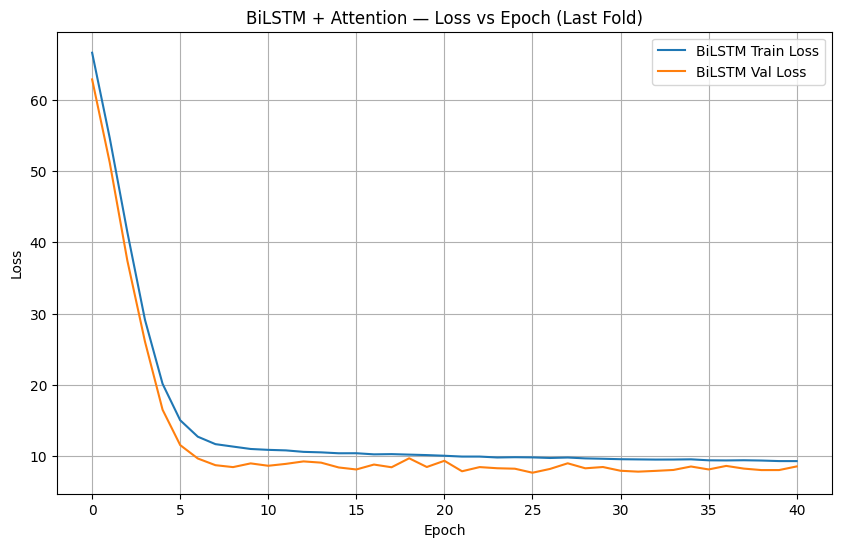

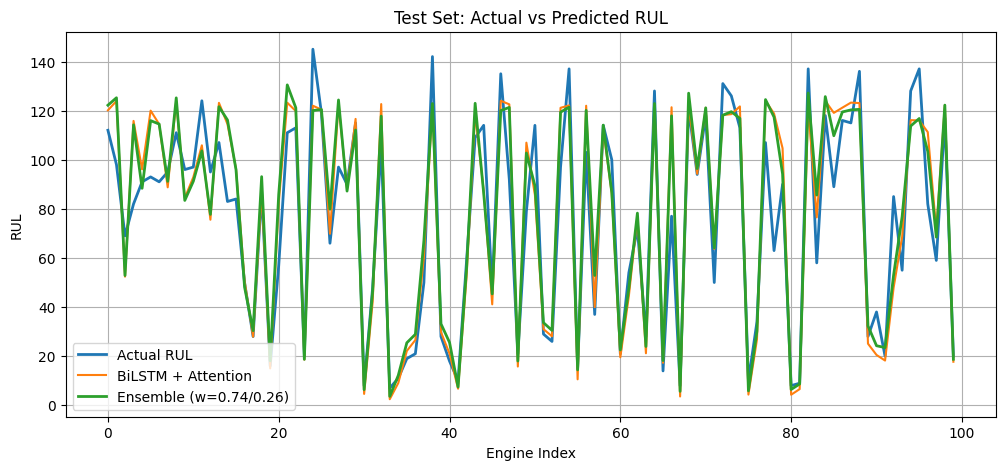

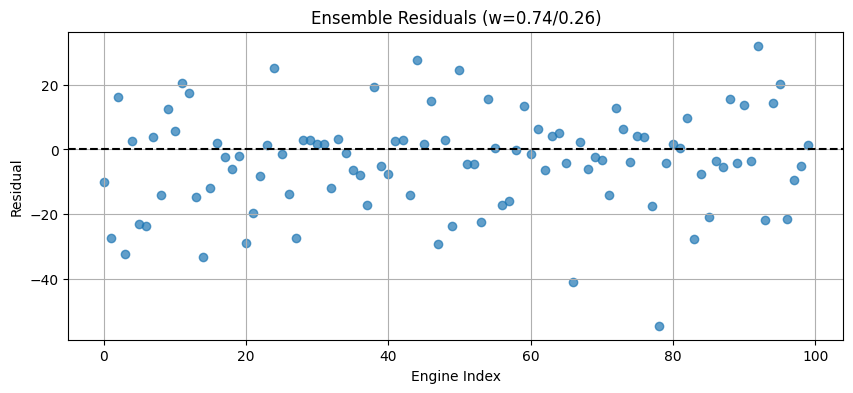

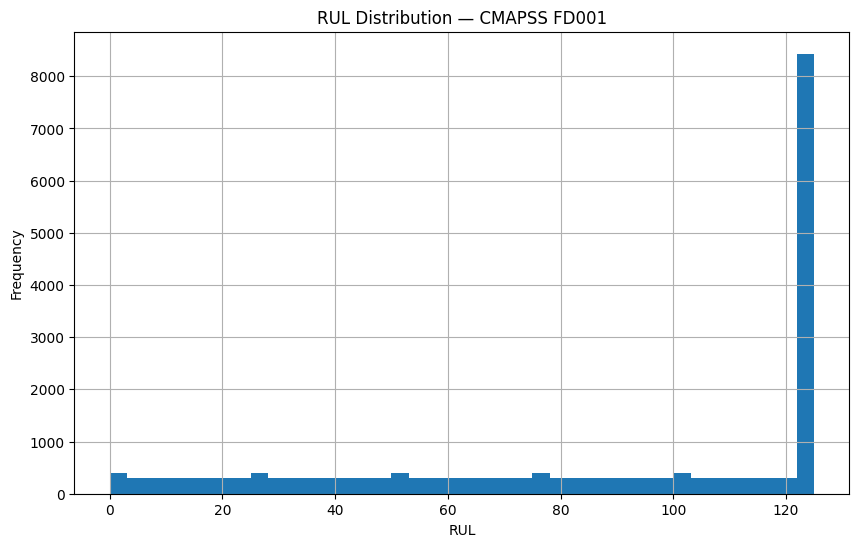

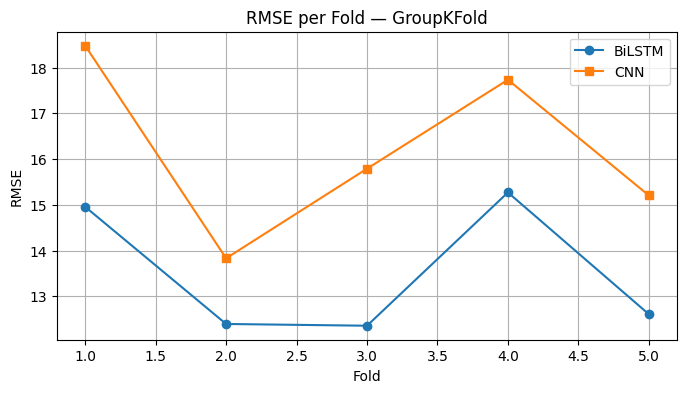

In [8]:

# ══════════════════════════════════════════════════════════════════════════════
# 10. TEST SET — final_scaler (trained on all train data) used here ✅
# ══════════════════════════════════════════════════════════════════════════════
test_df = pd.read_csv("test_FD001.txt", sep=r"\s+", header=None).iloc[:, :26]
test_df.columns = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

test_eng, _ = engineer_features(test_df, base_feature_cols)
test_eng[feat_cols] = final_scaler.transform(test_eng[feat_cols])   # transform only ✅

X_test = np.array([
    test_eng[test_eng['id'] == eid][feat_cols].values[-SEQUENCE_LENGTH:]
    for eid in test_eng['id'].unique()
], dtype=np.float32)

y_test = pd.read_csv("RUL_FD001.txt", header=None).values.flatten()

pred_lstm     = final_bilstm.predict(X_test, verbose=0).flatten()
pred_cnn      = final_cnn.predict(X_test,    verbose=0).flatten()
pred_ensemble = w_lstm * pred_lstm + w_cnn * pred_cnn

print(f"\n{'='*55}")
print("  TEST RESULTS")
print(f"{'='*55}")
report_metrics("CNN   + Attention",     y_test, pred_cnn)
report_metrics("BiLSTM + Attention",    y_test, pred_lstm)
report_metrics("Ensemble (optimized)",  y_test, pred_ensemble)

# ══════════════════════════════════════════════════════════════════════════════
# 11. PLOTS
# ══════════════════════════════════════════════════════════════════════════════
plt.figure(figsize=(10,6))
plt.plot(lstm_histories[-1].history['loss'],     label='BiLSTM Train Loss')
plt.plot(lstm_histories[-1].history['val_loss'], label='BiLSTM Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('BiLSTM + Attention — Loss vs Epoch (Last Fold)')
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(12,5))
plt.plot(y_test,        label='Actual RUL',                                linewidth=2)
plt.plot(pred_lstm,     label='BiLSTM + Attention',                        linewidth=1.5)
plt.plot(pred_ensemble, label=f'Ensemble (w={w_lstm:.2f}/{w_cnn:.2f})',    linewidth=2)
plt.title('Test Set: Actual vs Predicted RUL')
plt.xlabel('Engine Index'); plt.ylabel('RUL')
plt.legend(); plt.grid(); plt.show()

residuals = y_test - pred_ensemble
plt.figure(figsize=(10,4))
plt.scatter(range(len(residuals)), residuals, alpha=0.7)
plt.axhline(y=0, linestyle='--', color='black')
plt.title(f'Ensemble Residuals (w={w_lstm:.2f}/{w_cnn:.2f})')
plt.xlabel('Engine Index'); plt.ylabel('Residual')
plt.grid(); plt.show()

plt.figure(figsize=(10,6))
plt.hist(train_df['RUL'], bins=40)
plt.xlabel('RUL'); plt.ylabel('Frequency')
plt.title('RUL Distribution — CMAPSS FD001')
plt.grid(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(range(1, N_SPLITS+1), lstm_rmses, marker='o', label='BiLSTM')
plt.plot(range(1, N_SPLITS+1), cnn_rmses,  marker='s', label='CNN')
plt.xlabel('Fold'); plt.ylabel('RMSE')
plt.title('RMSE per Fold — GroupKFold')
plt.legend(); plt.grid(); plt.show()